In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from faker import Faker
import random
faker=Faker()
data=[]
for _ in range(200):
    data.append({
        "student_id":faker.uuid4(),
        "math":random.randint(50,90),
        "science":random.randint(50,90),
        "english":random.randint(50,90),
        "attendence_percent":random.randint(50,100)
    })
df=pd.DataFrame(data)
df.to_csv("AStudent_Academic.csv")


In [4]:
df.head()

,student_id,math,science,english,attendence_percent
0,d929fb7f-b0a1-46cf-8b2c-1f36a8fb32ee,89,88,82,84
1,006a1130-f08e-40e9-92a9-4226ac8d3746,86,57,85,90
2,6b18b2d3-e97b-42ca-ac16-eb28e1db8413,67,59,66,95
3,7eb2aa40-41c3-408f-9bd3-909dbe5dfd03,52,54,70,74
4,58c223b7-4724-4d83-b1bd-94b31e44193b,64,89,89,82


In [13]:
df['total_score']=df.groupby('student_id')[['math','science','english']].transform('sum').sum(axis=1)
df.head()

,student_id,math,science,english,attendence_percent,total_score
0,d929fb7f-b0a1-46cf-8b2c-1f36a8fb32ee,89,88,82,84,259
1,006a1130-f08e-40e9-92a9-4226ac8d3746,86,57,85,90,228
2,6b18b2d3-e97b-42ca-ac16-eb28e1db8413,67,59,66,95,192
3,7eb2aa40-41c3-408f-9bd3-909dbe5dfd03,52,54,70,74,176
4,58c223b7-4724-4d83-b1bd-94b31e44193b,64,89,89,82,242


In [14]:
df['avg_score']=df.groupby('student_id')[['math','science','english']].transform('mean').mean(axis=1)
df.head()

,student_id,math,science,english,attendence_percent,total_score,avg_score
0,d929fb7f-b0a1-46cf-8b2c-1f36a8fb32ee,89,88,82,84,259,86.333333
1,006a1130-f08e-40e9-92a9-4226ac8d3746,86,57,85,90,228,76.000000
2,6b18b2d3-e97b-42ca-ac16-eb28e1db8413,67,59,66,95,192,64.000000
3,7eb2aa40-41c3-408f-9bd3-909dbe5dfd03,52,54,70,74,176,58.666667
4,58c223b7-4724-4d83-b1bd-94b31e44193b,64,89,89,82,242,80.666667


In [15]:
df['weighted_score']=(df['math']*33.33+df['english']*33.33+df['science']*33.33)
df.head()

,student_id,math,science,english,attendence_percent,total_score,avg_score,weighted_score
0,d929fb7f-b0a1-46cf-8b2c-1f36a8fb32ee,89,88,82,84,259,86.333333,8632.47
1,006a1130-f08e-40e9-92a9-4226ac8d3746,86,57,85,90,228,76.000000,7599.24
2,6b18b2d3-e97b-42ca-ac16-eb28e1db8413,67,59,66,95,192,64.000000,6399.36
3,7eb2aa40-41c3-408f-9bd3-909dbe5dfd03,52,54,70,74,176,58.666667,5866.08
4,58c223b7-4724-4d83-b1bd-94b31e44193b,64,89,89,82,242,80.666667,8065.86


In [16]:
df['math_std']=(df['math']-np.mean(df['math']))/np.std(df['math'])
df['English_std']=(df['english']-np.mean(df['english']))/np.std(df['english'])
df['science_std']=(df['science']-np.mean(df['science']))/np.std(df['science'])
df.head()

,student_id,math,science,english,attendence_percent,total_score,avg_score,weighted_score,math_std,English_std,science_std
0,d929fb7f-b0a1-46cf-8b2c-1f36a8fb32ee,89,88,82,84,259,86.333333,8632.47,1.456024,0.877947,1.545260
1,006a1130-f08e-40e9-92a9-4226ac8d3746,86,57,85,90,228,76.000000,7599.24,1.214561,1.134407,-1.101318
2,6b18b2d3-e97b-42ca-ac16-eb28e1db8413,67,59,66,95,192,64.000000,6399.36,-0.314707,-0.489838,-0.930571
3,7eb2aa40-41c3-408f-9bd3-909dbe5dfd03,52,54,70,74,176,58.666667,5866.08,-1.522024,-0.147892,-1.357438
4,58c223b7-4724-4d83-b1bd-94b31e44193b,64,89,89,82,242,80.666667,8065.86,-0.556171,1.476354,1.630633


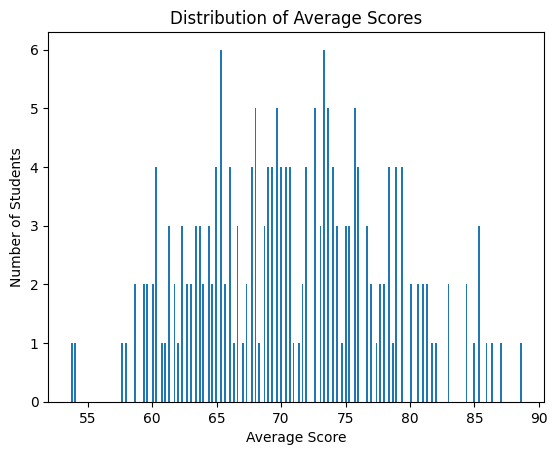

In [20]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['avg_score'], bins=250)
plt.title("Distribution of Average Scores")
plt.xlabel("Average Score")
plt.ylabel("Number of Students")
plt.show()

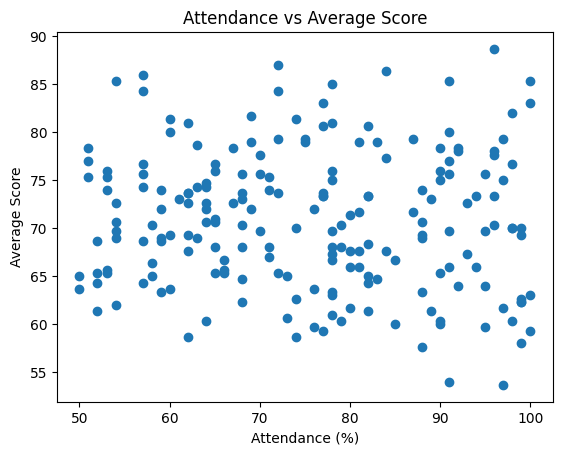

In [18]:
plt.figure()
plt.scatter(df['attendence_percent'], df['avg_score'])
plt.title("Attendance vs Average Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Average Score")
plt.show()